MLP with training schedulers

In [1]:
# Make use of a GPU or MPS (Apple) if one is available.  (see module 3.2)
import pandas
import torch
import pandas as pd
import numpy as np
from torch import nn, optim
import Training_options
device = Training_options.assess_device()
print(device)

cpu


In [2]:
from pathlib import Path
import os
import matplotlib.pyplot as plt
import time
from torch.utils.data import DataLoader

In [3]:
PROJECT_DIR = Path.cwd()
PREPARED_DIR = PROJECT_DIR / "outputs" / "prepared_notebook"
RUN_DIR = PROJECT_DIR / "outputs" / "training_options" 

In [4]:
lookBack = 28
maxStores = None
historyStart = None
trainStride = 7
epochs = 50
l2_lambda = 1e-4
l1_lambda = 1e-5
patience = 30
#MLP
BatchSize = 1024

In [5]:
data_dict = Training_options.read_split(test = os.path.join(PREPARED_DIR,"test_prepared.csv"), train = os.path.join(PREPARED_DIR,"train_prepared.csv"), valid = os.path.join(PREPARED_DIR,"validation_prepared.csv"), device=device)

In [6]:
train_df = data_dict["traindf"]
val_df = data_dict["valdf"]
test_df = data_dict["testdf"]
selectedStores = data_dict["selectedStores"]
eligibleStores = data_dict["eligibleStores"]
horizon = data_dict["Horizon"]
valDates = data_dict["valDates"]
testDates = data_dict["testDates"]
fullPreparedtestRows = data_dict["fullPreparedtestRows"]
categorical_features = data_dict["categoricalFeatures"]
numeric_features = data_dict["numericalFeatures"]

display(pd.DataFrame([
    {"split": name, "rows": len(frame), "stores": frame["Store"].nunique(),
     "start": frame["Date"].min().date(), "end": frame["Date"].max().date()}
    for name, frame in [("train", train_df), ("validation", val_df), ("test", test_df)]
]))

print(f"Selected {len(selectedStores)} of {len(eligibleStores)} eligible stores.")
print(f"Training Hroeizon: {horizon} days; validation: {len(valDates)}; test: {len(testDates)}.")
print(f"Test coverage: {len(test_df):,} / {fullPreparedtestRows:,} prepared rows.")

,split,rows,stores,start,end
0,train,737279,856,2013-01-01,2015-06-19
1,validation,35952,856,2015-06-20,2015-07-31
2,test,41088,856,2015-08-01,2015-09-17


Selected 856 of 856 eligible stores.
Training Hroeizon: 48 days; validation: 42; test: 48.
Test coverage: 41,088 / 41,088 prepared rows.


In [7]:
numeric_means = train_df[numeric_features].astype(float).mean().fillna(0.0)
numeric_stds = train_df[numeric_features].astype(float).std(ddof=0).replace(0, 1).fillna(1.0)
category_levels = {
    col: sorted(train_df[col].fillna("missing").astype(str).unique().tolist())
    for col in categorical_features
}
store_to_index = {int(store): i for i, store in enumerate(selectedStores)}
train_log_sales = np.log1p(train_df["Sales"].to_numpy(dtype=np.float64))
sales_mean = float(train_log_sales.mean())
sales_std = max(float(train_log_sales.std()), 1e-6)

encoded_feature_names = numeric_features.copy()
for col, levels in category_levels.items():
    encoded_feature_names.extend([f"{col}={level}" for level in levels] + [f"{col}=unknown"])

print("Features per future day:", len(encoded_feature_names))
print("Features per historical day:", len(encoded_feature_names) + 1)
print("Log-sales training mean/std:", round(sales_mean, 3), round(sales_std, 3))

Features per future day: 47
Features per historical day: 48
Log-sales training mean/std: 7.251 3.317


Training windows: 95384
Skipped windows crossing missing dates: 1800
One history: (28, 48)
One future feature block: (48, 47)
One target block: (48,)


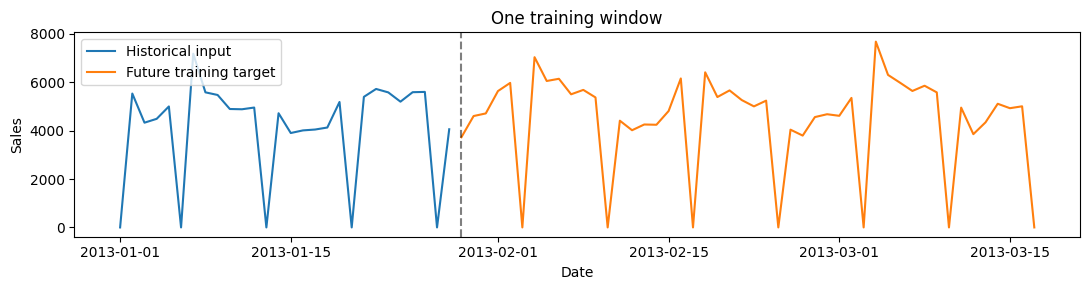

In [8]:

train_dataset = Training_options.SalesWindowDataset(train_df, lookBack, horizon, trainStride, store_to_index, numeric_features, numeric_means, category_levels, numeric_stds, sales_mean, sales_std)

example_history, example_future, example_store, example_target = train_dataset[0]
print("Training windows:", len(train_dataset))
print("Skipped windows crossing missing dates:", train_dataset.skipped_windows)
print("One history:", tuple(example_history.shape))
print("One future feature block:", tuple(example_future.shape))
print("One target block:", tuple(example_target.shape))

store_id, start = train_dataset.windows[0]
history, _, target, dates = train_dataset.series[store_id]
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(dates[start - lookBack:start], np.expm1(history[start - lookBack:start, 0] * sales_std + sales_mean),
        label="Historical input")
ax.plot(dates[start:start + horizon], np.expm1(target[start:start + horizon] * sales_std + sales_mean),
        label="Future training target")
ax.axvline(dates[start], color="black", linestyle="--", alpha=0.5)
ax.set(title="One training window", xlabel="Date", ylabel="Sales")
ax.legend()
fig.tight_layout()
plt.show()

In [9]:
val_inputs, val_rows = Training_options.make_forecast_inputs(train_df, val_df.drop(columns="Sales"), horizon, lookBack, store_to_index,
                                                             numeric_features,numeric_means, category_levels, numeric_stds,
                                                             sales_mean, sales_std)
val_labels = val_rows[["Store", "Date"]].merge(
    val_df[["Store", "Date", "Sales"]], on=["Store", "Date"],
    how="left", validate="one_to_one", sort=False
)["Sales"].to_numpy()
assert np.isfinite(val_labels).all()
print("Validation input shapes:", [tuple(tensor.shape) for tensor in val_inputs])
print("Last historical date:", valDates[0] - pd.Timedelta(days=1))
print("First forecast date:", valDates[0])

Validation input shapes: [(856, 28, 48), (856, 42, 47), (856,)]
Last historical date: 2015-06-19 00:00:00
First forecast date: 2015-06-20 00:00:00


# MLP

In [10]:
mlP_categorical_features = ["Store", "DayOfWeek","StateHoliday", "StoreType", "Assortment"]
mlp_train_df = train_df
mlp_val_df = val_df

category_maps = {}
category_cardinalities = {}
for column in mlP_categorical_features:
    values = sorted(Training_options.as_category_text(mlp_train_df[column]).unique())
    mapping = {"unknown": 0}
    mapping.update({value: index + 1 for index, value in enumerate(values)})
    category_maps[column] = mapping
    category_cardinalities[column] = len(mapping)

train_cat = Training_options.encode_categorical_frame(mlp_train_df, mlP_categorical_features, category_maps)
val_cat = Training_options.encode_categorical_frame(mlp_val_df, mlP_categorical_features, category_maps)
test_cat = Training_options.encode_categorical_frame(test_df, mlP_categorical_features, category_maps)

category_summary = pd.DataFrame(
    {
        "feature": list(category_cardinalities.keys()),
        "n_categories_including_unknown": list(category_cardinalities.values()),
    }
)

display(category_summary)

train_num = Training_options.scale_numeric_frame(mlp_train_df, numeric_features, numeric_means, numeric_stds)
val_num = Training_options.scale_numeric_frame(val_df, numeric_features, numeric_means, numeric_stds)
test_num = Training_options.scale_numeric_frame(test_df, numeric_features, numeric_means, numeric_stds)

display(train_num.head())


mlp_train_df["log_sales"] = np.log1p(mlp_train_df["Sales"].clip(lower = 0))
mlp_val_df["log_sales"] = np.log1p(mlp_val_df["Sales"].clip(lower = 0))

mlp_train_dataset = Training_options.StoreSalesDataset(train_cat, train_num, mlp_train_df["log_sales"])
mlp_val_dataset = Training_options.StoreSalesDataset(val_cat, val_num, mlp_val_df["log_sales"])
mlp_test_dataset = Training_options.StoreSalesDataset(test_cat, test_num)

mlp_train_loader = Training_options.make_dataloader(mlp_train_dataset, batch_size=BatchSize, shuffle=True)
mlp_val_loader = Training_options.make_dataloader(mlp_val_dataset, batch_size=BatchSize, shuffle=False)
mlp_test_loader = Training_options.make_dataloader(mlp_test_dataset, batch_size=BatchSize, shuffle=False)

print("train batches:", len(mlp_train_loader))
print("validation batches:", len(mlp_val_loader))
print("test batches:", len(mlp_test_loader))

embedding_cardinalities = [category_cardinalities[column] for column in mlP_categorical_features]
embedding_dimensions = [Training_options.embedding_size(cardinality) for cardinality in embedding_cardinalities]

print("Embedding cardinalities:", embedding_cardinalities)
print("Embedding dimensions:", embedding_dimensions)

,feature,n_categories_including_unknown
0,Store,857
1,DayOfWeek,8
2,StateHoliday,5
3,StoreType,5
4,Assortment,4


,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,year,...,is_weekend,is_month_start,is_month_end,days_since_start,competition_open_months,promo2_active,dow_sin,dow_cos,month_sin,month_cos
0,-2.199920,-0.78702,2.184374,-0.52644,1.092215,0.770983,-1.146088,-0.854765,-1.146087,-1.024758,...,-0.630617,5.382556,-0.182419,-1.682166,0.197809,-0.429971,1.378848,-0.311482,0.499684,1.277477
1,0.454562,-0.78702,2.184374,-0.52644,1.092215,0.770983,-1.146088,-0.854765,-1.146087,-1.024758,...,-0.630617,-0.185785,-0.182419,-1.678352,0.197809,-0.429971,0.613916,-1.271234,0.499684,1.277477
2,0.454562,-0.78702,2.184374,-0.52644,1.092215,0.770983,-1.146088,-0.854765,-1.146087,-1.024758,...,-0.630617,-0.185785,-0.182419,-1.674538,0.197809,-0.429971,-0.612940,-1.271234,0.499684,1.277477
3,0.454562,-0.78702,2.184374,-0.52644,1.092215,0.770983,-1.146088,-0.854765,-1.146087,-1.024758,...,-0.630617,-0.185785,-0.182419,-1.670724,0.197809,-0.429971,-1.377872,-0.311482,0.499684,1.277477
4,0.454562,-0.78702,2.184374,-0.52644,1.092215,0.770983,-1.146088,-0.854765,-1.146087,-1.024758,...,1.585749,-0.185785,-0.182419,-1.666910,0.197809,-0.429971,-1.104871,0.885308,0.499684,1.277477


train batches: 720
validation batches: 36
test batches: 41
Embedding cardinalities: [857, 8, 5, 5, 4]
Embedding dimensions: [50, 4, 2, 2, 2]


In [11]:
model = Training_options.TabularSalesModel_MLP(embedding_cardinalities=embedding_cardinalities, 
                                               embedding_dimensions= embedding_dimensions, 
                                               n_numeric_features= len(numeric_features), dropout=0.15)
model.to(device)
loss_function = nn.MSELoss()
optimizer = torch.optim.AdamW(params= model.parameters(), lr = 0.01, weight_decay=l2_lambda)
scheduler = Training_options.create_scheduler(optimizer)

m_res, hist, b_ep = Training_options.mlp_basic_training_loop(model, mlp_train_loader, loss_function, optimizer,
                                                            epochs, mlp_val_loader, scheduler, l1_lambda, patience,
                                                            0.001, 2, os.path.join(RUN_DIR, "mlp_scheduler.pt"),device)

Epoch 2/50, Train Loss: 0.1528, Validation Loss: 0.0389, Validation MAE: 0.1554
Epoch 4/50, Train Loss: 0.0685, Validation Loss: 0.0590, Validation MAE: 0.1933
Epoch 6/50, Train Loss: 0.0433, Validation Loss: 0.0344, Validation MAE: 0.1474
Epoch 8/50, Train Loss: 0.0301, Validation Loss: 0.0209, Validation MAE: 0.1064
Epoch 10/50, Train Loss: 0.0251, Validation Loss: 0.0249, Validation MAE: 0.1162
Epoch 12/50, Train Loss: 0.0263, Validation Loss: 0.0178, Validation MAE: 0.0951
Epoch 14/50, Train Loss: 0.0250, Validation Loss: 0.0309, Validation MAE: 0.1284
Epoch 16/50, Train Loss: 0.0262, Validation Loss: 0.0190, Validation MAE: 0.0985
Stopping at epoch 16. Early stopping triggered after 4 epochs.


In [12]:
print(hist["train_loss"])
print(hist["valid_loss"])
print(hist["valid_mae"])

[0.5688295810793836, 0.15275469223658245, 0.09985298755992618, 0.06851603787185417, 0.04619913124479354, 0.043254607370019786, 0.04040627760243499, 0.030134125924410504, 0.024988507461320194, 0.0250959222114438, 0.025037099743106712, 0.026265340723976908, 0.02547863704514586, 0.025047981169902617, 0.02592420963725696, 0.026189185068425207]
[0.07585706934498637, 0.0389296156480663, 0.06070945408936336, 0.05897984636800789, 0.029737588497310626, 0.03444867382015872, 0.031934195813612246, 0.020931424063261105, 0.02095790348141311, 0.02488043817016327, 0.030392298329013107, 0.017844518319992526, 0.01862520487953357, 0.030853525735852344, 0.03094781032242428, 0.0189542275135172]
[0.2141818402871377, 0.15539988828968035, 0.18926594222339993, 0.19334739072618878, 0.11959988157325815, 0.14743231650082123, 0.14231163568373623, 0.10638112559231536, 0.10803682007256964, 0.11620140836989025, 0.12897253819025511, 0.09509179342254619, 0.10003969546790435, 0.1284225378558537, 0.12818061870418765, 0.0

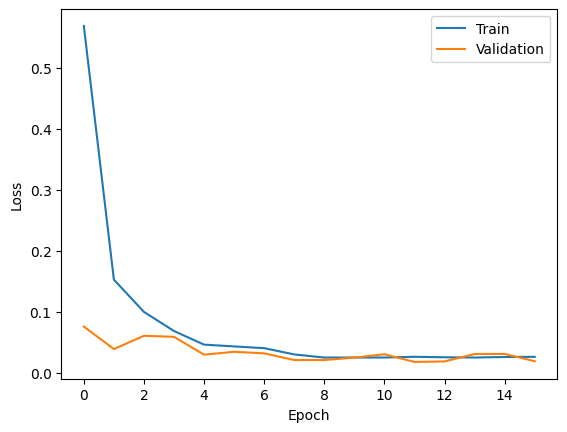

In [13]:
plt.plot(hist["train_loss"], label="Train")
plt.plot(hist["valid_loss"], label="Validation")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [14]:
m_res.eval()

predictions = []

with torch.inference_mode():
    for categorical_inputs, numeric_inputs in mlp_test_loader:
        categorical_inputs = categorical_inputs.to(device)
        numeric_inputs = numeric_inputs.to(device)

        preds = m_res(categorical_inputs, numeric_inputs)

        predictions.extend(preds.squeeze(-1).cpu().numpy())

# Convert predictions from normalized log-sales back to actual Sales
predicted_sales = np.expm1(predictions)
predicted_sales = np.maximum(predicted_sales, 0)

predicted_sales = np.where(test_df["Open"].to_numpy() == 0,0.0,predicted_sales)

test_predictions = pd.DataFrame({
    "Date": test_df["Date"].values,
    "Store": test_df["Store"].values,
    "Sales": predicted_sales
})

display(test_predictions.head())

,Date,Store,Sales
0,2015-08-01,1,4329.077148
1,2015-08-02,1,0.000000
2,2015-08-03,1,6289.930664
3,2015-08-04,1,5222.791992
4,2015-08-05,1,4784.563965


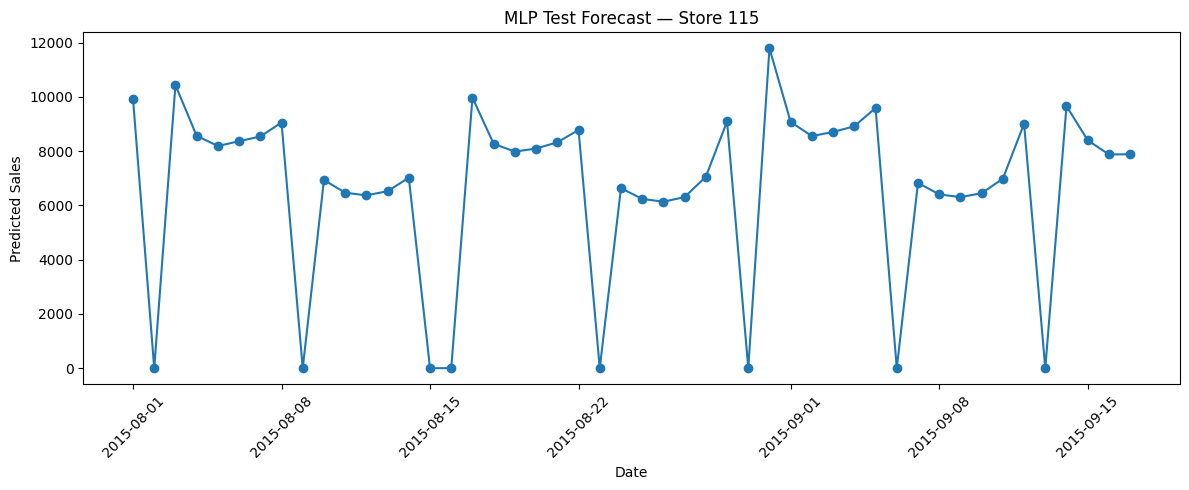

In [15]:
store_to_plot = 115

plot_df = test_predictions[
    test_predictions["Store"] == store_to_plot
]

plt.figure(figsize=(12, 5))

plt.plot(
    plot_df["Date"],
    plot_df["Sales"],
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Predicted Sales")
plt.title(f"MLP Test Forecast — Store {store_to_plot}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
m_res.eval()

val_predictions = []
y_val = []

with torch.inference_mode():
    for categorical_inputs, numeric_inputs, y_valid in mlp_val_loader:
        categorical_inputs = categorical_inputs.to(device)
        numeric_inputs = numeric_inputs.to(device)

        preds = m_res(categorical_inputs, numeric_inputs)

        val_predictions.extend(
            preds.squeeze(-1).cpu().numpy()
        )

        y_val.extend(
            y_valid.squeeze(-1).cpu().numpy()
        )

# Convert log1p(Sales) → original Sales scale
val_predicted_sales = np.expm1(val_predictions)
val_predicted_sales = np.maximum(val_predicted_sales, 0)

# Convert actual validation target → original Sales scale
val_predicted_sales = np.expm1(val_predictions)
val_actual_sales = np.maximum(np.expm1(y_val), 0)

metrics = Training_options.regression_metrics(
    val_actual_sales,
    val_predicted_sales
)

print("MLP Metrics", metrics)

MLP Metrics {'rmspe': 0.1538155561059447, 'mse': 1047071.75930308, 'rmse': 1023.2652438654799, 'mae': 654.9854461130673, 'r2': 0.9198236063629573}


# Recurrent Models

In [10]:
MODEL_TYPES = ("RNN", "LSTM", "GRU")
hiddenSize = 32
numLayers = 1
dropout = 0.15
STORE_EMBEDDING_SIZE = 8
LEARNING_RATE = 0.001
rnn_batchSize = 64

rnn_train_loader = DataLoader(
        train_dataset, batch_size=rnn_batchSize, shuffle=True, num_workers=0,
        generator=torch.Generator().manual_seed(42),
    )

test_inputs, test_rows = Training_options.make_forecast_inputs(
    train_df,
    test_df.drop(columns="Id"),
    horizon,
    lookBack,
    store_to_index,
    numeric_features,
    numeric_means,
    category_levels,
    numeric_stds,
    sales_mean,
    sales_std
)

Epoch 2/50, Train Loss: 0.0092, Validation Loss: 0.0024, Validation MAE: 727.7908
Epoch 4/50, Train Loss: 0.0091, Validation Loss: 0.0027, Validation MAE: 811.2086
Epoch 6/50, Train Loss: 0.0091, Validation Loss: 0.0023, Validation MAE: 757.4248
Epoch 8/50, Train Loss: 0.0091, Validation Loss: 0.0021, Validation MAE: 706.8547
Epoch 10/50, Train Loss: 0.0091, Validation Loss: 0.0019, Validation MAE: 685.5698
Epoch 12/50, Train Loss: 0.0090, Validation Loss: 0.0021, Validation MAE: 703.6848
Epoch 14/50, Train Loss: 0.0090, Validation Loss: 0.0023, Validation MAE: 726.5850
Epoch 16/50, Train Loss: 0.0090, Validation Loss: 0.0018, Validation MAE: 666.0948
Epoch 18/50, Train Loss: 0.0090, Validation Loss: 0.0023, Validation MAE: 752.6374
Epoch 20/50, Train Loss: 0.0089, Validation Loss: 0.0020, Validation MAE: 719.9759
Epoch 22/50, Train Loss: 0.0089, Validation Loss: 0.0018, Validation MAE: 662.2733
Epoch 24/50, Train Loss: 0.0089, Validation Loss: 0.0022, Validation MAE: 709.0476
Epoch 26

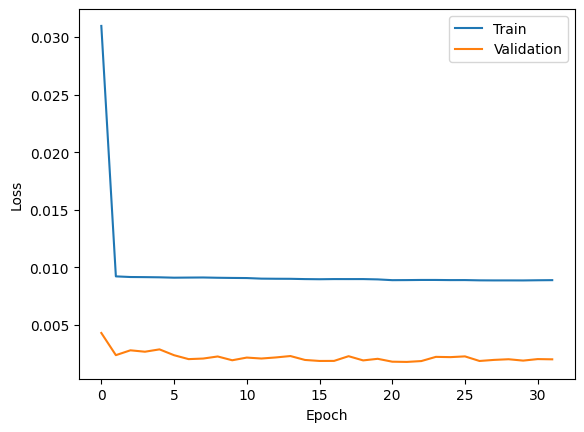

[4097    0 3846 3762 3346 3533 3317 4019    0 5197]
5953.514380284824 0 41551
[ 0.30849522 -2.160738    0.2840714   0.26964062  0.27118254  0.27372265
  0.306489    0.31505358 -2.1618574   0.4280535 ]
-2.2440495 0.8754027
scaled min: -2.1821723
scaled max: 0.18367715
finite: True
largest predictions: [0.1595826  0.15960883 0.16073431 0.16140835 0.16173114 0.16733459
 0.1679546  0.16917774 0.17136277 0.18367715]
Test history finite: True
Test future finite: True


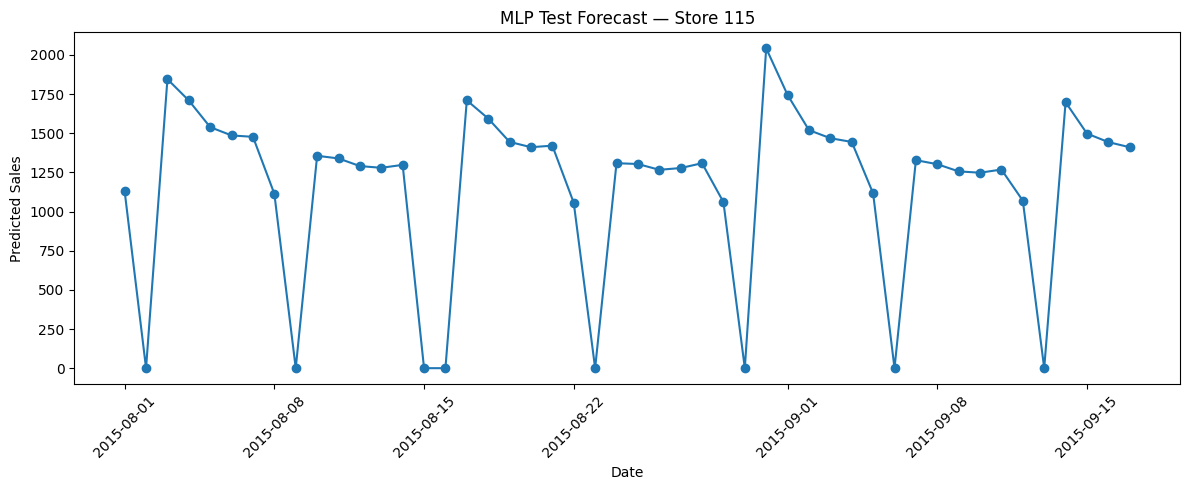

RNN Metrics {'rmspe': 0.16484092891593566, 'mse': 1340653.3034337019, 'rmse': 1157.8658399977528, 'mae': 727.790783531296, 'r2': 0.8973434747139958}
Epoch 2/50, Train Loss: 0.0085, Validation Loss: 0.0020, Validation MAE: 721.8098
Epoch 4/50, Train Loss: 0.0084, Validation Loss: 0.0022, Validation MAE: 729.5796
Epoch 6/50, Train Loss: 0.0084, Validation Loss: 0.0023, Validation MAE: 710.9373
Epoch 8/50, Train Loss: 0.0084, Validation Loss: 0.0019, Validation MAE: 668.7658
Epoch 10/50, Train Loss: 0.0083, Validation Loss: 0.0018, Validation MAE: 657.6941
Epoch 12/50, Train Loss: 0.0083, Validation Loss: 0.0019, Validation MAE: 678.9856
Epoch 14/50, Train Loss: 0.0083, Validation Loss: 0.0019, Validation MAE: 671.2984
Epoch 16/50, Train Loss: 0.0083, Validation Loss: 0.0022, Validation MAE: 763.7140
Epoch 18/50, Train Loss: 0.0083, Validation Loss: 0.0021, Validation MAE: 709.7798
Epoch 20/50, Train Loss: 0.0083, Validation Loss: 0.0018, Validation MAE: 667.2590
Epoch 22/50, Train Loss: 

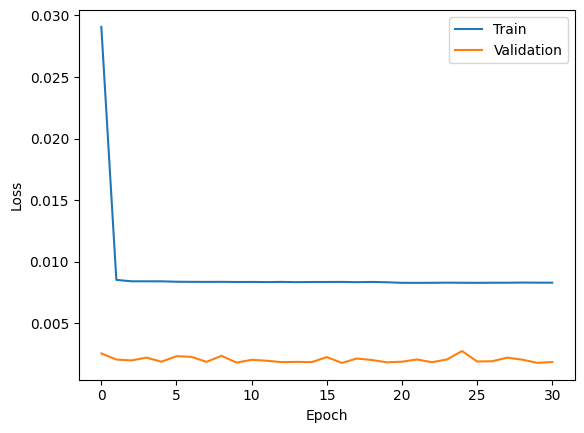

[4097    0 3846 3762 3346 3533 3317 4019    0 5197]
5953.514380284824 0 41551
[ 0.26425582 -2.1349564   0.2586406   0.2414084   0.24800919  0.24973817
  0.2820713   0.26868415 -2.1364229   0.3928951 ]
-2.1706114 0.8387689
scaled min: -2.2137408
scaled max: 0.51082194
finite: True
largest predictions: [0.4042993  0.40503433 0.41040966 0.4190242  0.4439844  0.4463163
 0.4694053  0.4695342  0.4954995  0.51082194]
Test history finite: True
Test future finite: True


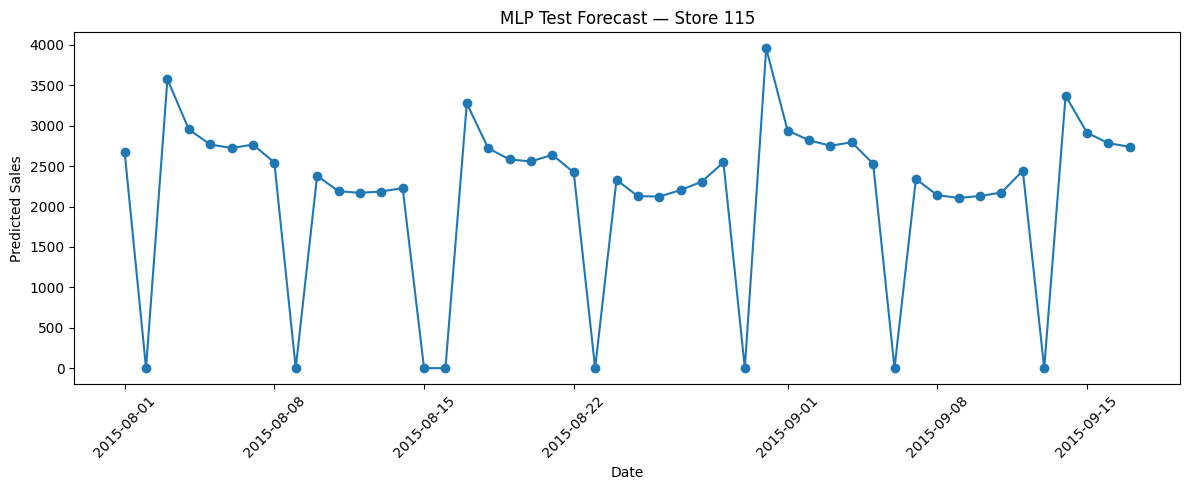

LSTM Metrics {'rmspe': 0.1831539547256354, 'mse': 1384784.7325537931, 'rmse': 1176.7687676658456, 'mae': 724.586305543577, 'r2': 0.8939642422474283}
Epoch 2/50, Train Loss: 0.0086, Validation Loss: 0.0019, Validation MAE: 669.5378
Epoch 4/50, Train Loss: 0.0084, Validation Loss: 0.0018, Validation MAE: 655.9378
Epoch 6/50, Train Loss: 0.0084, Validation Loss: 0.0018, Validation MAE: 662.1295
Epoch 8/50, Train Loss: 0.0083, Validation Loss: 0.0022, Validation MAE: 752.2319
Epoch 10/50, Train Loss: 0.0082, Validation Loss: 0.0018, Validation MAE: 662.3800
Epoch 12/50, Train Loss: 0.0082, Validation Loss: 0.0021, Validation MAE: 734.5449
Epoch 14/50, Train Loss: 0.0082, Validation Loss: 0.0018, Validation MAE: 672.2735
Epoch 16/50, Train Loss: 0.0082, Validation Loss: 0.0018, Validation MAE: 663.1195
Epoch 18/50, Train Loss: 0.0082, Validation Loss: 0.0020, Validation MAE: 661.2828
Epoch 20/50, Train Loss: 0.0082, Validation Loss: 0.0017, Validation MAE: 642.7585
Epoch 22/50, Train Loss: 

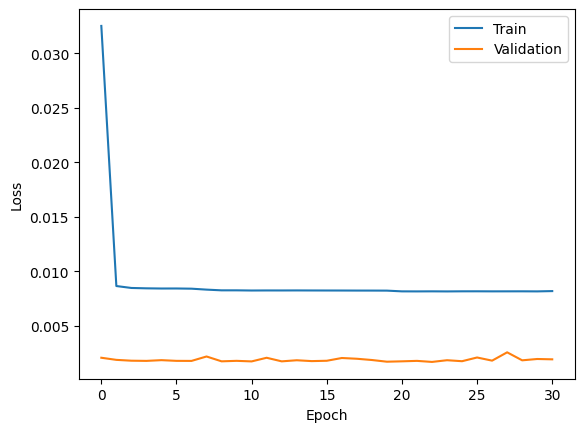

[4097    0 3846 3762 3346 3533 3317 4019    0 5197]
5953.514380284824 0 41551
[ 0.3130157  -2.1431267   0.31466407  0.28251413  0.28058547  0.29055488
  0.32886663  0.32311803 -2.1440313   0.4532851 ]
-2.1719031 0.8067705
scaled min: -2.3098323
scaled max: 0.23364618
finite: True
largest predictions: [0.22848615 0.2288965  0.22919226 0.22924724 0.22942796 0.22988418
 0.23102039 0.23103431 0.2327975  0.23364618]
Test history finite: True
Test future finite: True


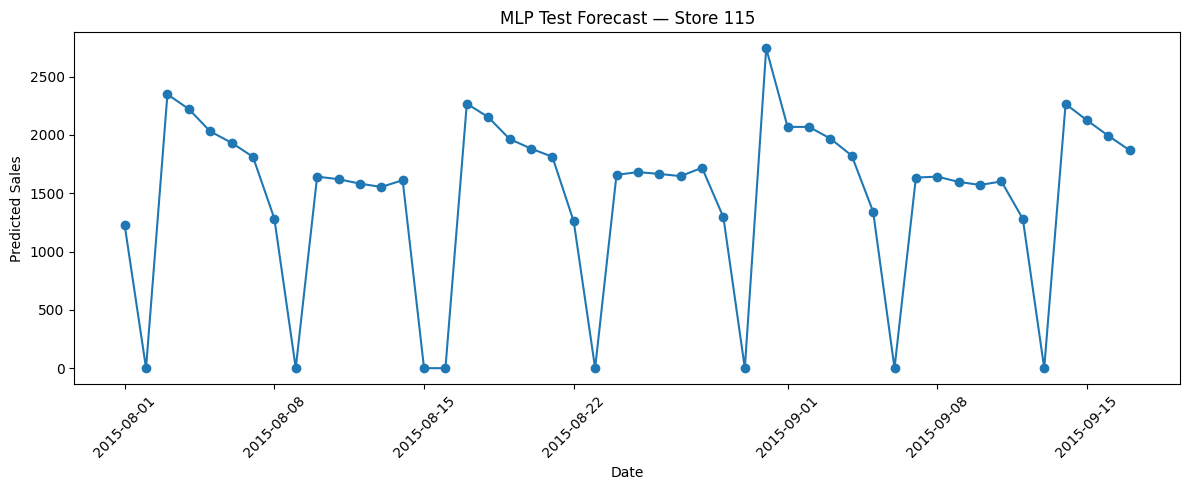

GRU Metrics {'rmspe': 0.16596936120147845, 'mse': 1232238.4701707205, 'rmse': 1110.0623721983916, 'mae': 698.1286477836384, 'r2': 0.9056450169872547}


In [15]:
for model_type in MODEL_TYPES:
    model = Training_options.RecurrentSalesModel(model_type, encoded_feature_names,hiddenSize, numLayers, dropout, STORE_EMBEDDING_SIZE, selectedStores)
    model.to(device)
    loss_function = nn.MSELoss()
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=l2_lambda)
    scheduler = Training_options.create_scheduler(optimizer)
    
    trained_model, history_frame, best_epoch = Training_options.recurrent_training_loop(model,rnn_train_loader,loss_function, optimizer,epochs, val_inputs, val_rows,val_labels, scheduler,
                                                                                        l1_lambda, patience, 0.001,2, os.path.join(RUN_DIR, "rnn_scheduler.pt"),device, rnn_batchSize, sales_std, sales_mean, horizon )

    plt.plot(history_frame["train_loss"], label="Train")
    plt.plot(history_frame["valid_loss"], label="Validation")
    plt.legend()
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

    print(val_labels[:10])
    print(val_labels.mean(), val_labels.min(), val_labels.max())

    print(val_scaled[:10])
    print(val_scaled.min(), val_scaled.max())

    trained_model.eval()
    outputs = []
    with torch.inference_mode():
        for start in range(0, len(test_inputs[0]), rnn_batchSize):
            batch = [tensor[start:start + rnn_batchSize].to(device) for tensor in test_inputs]
            outputs.append(trained_model(*batch, horizon).cpu().numpy())

    test_scaled = np.concatenate(outputs, axis=0).ravel()

    print("scaled min:", np.min(test_scaled))
    print("scaled max:", np.max(test_scaled))
    print("finite:", np.isfinite(test_scaled).all())

    print("largest predictions:",
      np.sort(test_scaled)[-10:])

    print("Test history finite:",
      np.isfinite(test_inputs[0].numpy()).all())

    print("Test future finite:",
      np.isfinite(test_inputs[1].numpy()).all())

    test_predictions_sales = Training_options.decode_sales(
    test_scaled,
    test_rows["Open"].to_numpy(), sales_std, sales_mean)

    test_predictions = test_rows[["Store", "Date"]].copy()

    test_predictions["Sales"] = test_predictions_sales

    store_to_plot = 115

    plot_df = test_predictions[
        test_predictions["Store"] == store_to_plot
    ]

    plt.figure(figsize=(12, 5))

    plt.plot(
        plot_df["Date"],
        plot_df["Sales"],
        marker="o"
    )

    plt.xlabel("Date")
    plt.ylabel("Predicted Sales")
    plt.title(f"MLP Test Forecast — Store {store_to_plot}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    trained_model.eval()
    outputs = []
    with torch.inference_mode():
        for start in range(0, len(val_inputs[0]), rnn_batchSize):
            batch = [tensor[start:start + rnn_batchSize].to(device) for tensor in val_inputs]
            outputs.append(trained_model(*batch, horizon).cpu().numpy())

    val_scaled = np.concatenate(outputs, axis=0).ravel()

    val_predictions_sales = Training_options.decode_sales(
    val_scaled,
    val_rows["Open"].to_numpy(),sales_std, sales_mean)

    metrics = Training_options.regression_metrics(
    val_labels,
    val_predictions_sales)

    print(model_type, "Metrics", metrics)